<a href="https://colab.research.google.com/github/partha1923/ITA0608-ML/blob/main/exp_3_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Dataset:

     Outlook Temperature Humidity    Wind Play
0      Sunny         Hot     High    Weak   No
1      Sunny         Hot     High  Strong   No
2   Overcast         Hot     High    Weak  Yes
3       Rain        Mild     High    Weak  Yes
4       Rain        Cool   Normal    Weak  Yes
5       Rain        Cool   Normal  Strong   No
6   Overcast        Cool   Normal  Strong  Yes
7      Sunny        Mild     High    Weak   No
8      Sunny        Cool   Normal    Weak  Yes
9       Rain        Mild   Normal    Weak  Yes
10     Sunny        Mild   Normal  Strong  Yes
11  Overcast        Mild     High  Strong  Yes
12  Overcast         Hot   Normal    Weak  Yes
13      Rain        Mild     High  Strong   No

Encoded Dataset:

    Outlook  Temperature  Humidity  Wind  Play
0         2            1         0     1     0
1         2            1         0     0     0
2         0            1         0     1     1
3         1            2         0     1     1
4         1           

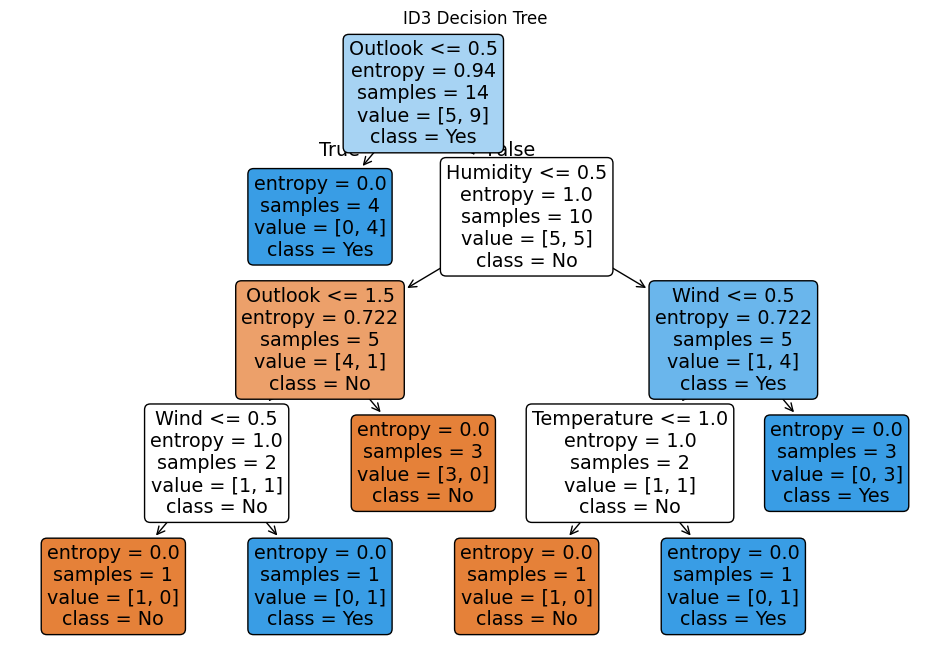


Prediction for New Sample:
Sunny, Cool, High, Weak
Play Tennis = No


In [1]:
# Import libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Create the dataset
# -----------------------------
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain',
                'Overcast', 'Sunny', 'Sunny', 'Rain', 'Sunny',
                'Overcast', 'Overcast', 'Rain'],

    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool',
                    'Cool', 'Mild', 'Cool', 'Mild', 'Mild',
                    'Mild', 'Hot', 'Mild'],

    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal',
                 'Normal', 'High', 'Normal', 'Normal', 'Normal',
                 'High', 'Normal', 'High'],

    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong',
             'Strong', 'Weak', 'Weak', 'Weak', 'Strong',
             'Strong', 'Weak', 'Strong'],

    'Play': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No',
             'Yes', 'No', 'Yes', 'Yes', 'Yes',
             'Yes', 'Yes', 'No']
}

df = pd.DataFrame(data)

print("Original Dataset:\n")
print(df)

# -----------------------------
# Step 2: Encode categorical data
# -----------------------------
label_encoders = {}

for column in df.columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

print("\nEncoded Dataset:\n")
print(df)

# -----------------------------
# Step 3: Split features & target
# -----------------------------
X = df.drop("Play", axis=1)
y = df["Play"]

# -----------------------------
# Step 4: Train ID3 Decision Tree
# -----------------------------
model = DecisionTreeClassifier(
    criterion="entropy",   # ID3 uses entropy
    random_state=42
)

model.fit(X, y)

# -----------------------------
# Step 5: Plot the decision tree
# -----------------------------
plt.figure(figsize=(12,8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=label_encoders['Play'].classes_,
    filled=True,
    rounded=True
)

plt.title("ID3 Decision Tree")
plt.show()

# -----------------------------
# Step 6: Predict a new sample
# New Sample:
# Outlook = Sunny
# Temperature = Cool
# Humidity = High
# Wind = Weak
# -----------------------------

new_sample = pd.DataFrame({
    'Outlook': ['Sunny'],
    'Temperature': ['Cool'],
    'Humidity': ['High'],
    'Wind': ['Weak']
})

# Encode the new sample
for col in new_sample.columns:
    new_sample[col] = label_encoders[col].transform(new_sample[col])

prediction = model.predict(new_sample)

result = label_encoders['Play'].inverse_transform(prediction)

print("\nPrediction for New Sample:")
print("Sunny, Cool, High, Weak")
print("Play Tennis =", result[0])